###### 131_6_countermeasure_tag_dummy_practice.ipynb

In [2]:
#cell 1

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [10]:
df = pd.read_csv("dataset/countermeasure_tag.csv")
df

,defect_id,site,model,occ_month,defect_qty,countermeasure_tag
0,D001,SUS,J69P,2026-07,3,"外観検査,通電検査"
1,D002,SUS,310D,2026-07,2,設計変更
2,D003,WSE,36WA,2026-07,1,"教育,作業標準改訂"
3,D004,GSE,3BVT,2026-08,4,"通電検査,作業標準改訂"
4,D005,META,J69P,2026-08,2,外観検査
5,D006,META,310D,2026-08,5,"設計変更,通電検査"
6,D007,MEAX,36WA,2026-09,1,教育
7,D008,MELAC,3BVT,2026-09,3,"外観検査,設計変更"
8,D009,SUS,36WA,2026-09,2,作業標準改訂
9,D010,WSE,J69P,2026-10,4,"外観検査,教育"


In [11]:
df["countermeasure_tag"]

0        外観検査,通電検査
1             設計変更
2        教育,作業標準改訂
3      通電検査,作業標準改訂
4             外観検査
5        設計変更,通電検査
6               教育
7        外観検査,設計変更
8           作業標準改訂
9          外観検査,教育
10     設計変更,作業標準改訂
11    通電検査,教育,設計変更
Name: countermeasure_tag, dtype: str

In [13]:
df_measure_dummy = df["countermeasure_tag"].str.get_dummies(sep=",")

In [15]:
df_measure_dummy

,作業標準改訂,外観検査,教育,設計変更,通電検査
0,0,1,0,0,1
1,0,0,0,1,0
2,1,0,1,0,0
3,1,0,0,0,1
4,0,1,0,0,0
5,0,0,0,1,1
6,0,0,1,0,0
7,0,1,0,1,0
8,1,0,0,0,0
9,0,1,1,0,0


In [16]:
#cell 7
df = df.join(df_measure_dummy)

In [17]:
df

,defect_id,site,model,occ_month,defect_qty,countermeasure_tag,作業標準改訂,外観検査,教育,設計変更,通電検査
0,D001,SUS,J69P,2026-07,3,"外観検査,通電検査",0,1,0,0,1
1,D002,SUS,310D,2026-07,2,設計変更,0,0,0,1,0
2,D003,WSE,36WA,2026-07,1,"教育,作業標準改訂",1,0,1,0,0
3,D004,GSE,3BVT,2026-08,4,"通電検査,作業標準改訂",1,0,0,0,1
4,D005,META,J69P,2026-08,2,外観検査,0,1,0,0,0
5,D006,META,310D,2026-08,5,"設計変更,通電検査",0,0,0,1,1
6,D007,MEAX,36WA,2026-09,1,教育,0,0,1,0,0
7,D008,MELAC,3BVT,2026-09,3,"外観検査,設計変更",0,1,0,1,0
8,D009,SUS,36WA,2026-09,2,作業標準改訂,1,0,0,0,0
9,D010,WSE,J69P,2026-10,4,"外観検査,教育",0,1,1,0,0


In [20]:
measure_cols = df_measure_dummy.columns.tolist()
measure_cols

['作業標準改訂', '外観検査', '教育', '設計変更', '通電検査']

In [21]:
df_measure_count = df[measure_cols].sum().reset_index()

In [22]:
df_measure_count

,index,0
0,作業標準改訂,4
1,外観検査,4
2,教育,4
3,設計変更,5
4,通電検査,4


In [23]:
df_measure_count.columns = ["measure", "count"]

In [24]:
df_measure_count

,measure,count
0,作業標準改訂,4
1,外観検査,4
2,教育,4
3,設計変更,5
4,通電検査,4


In [25]:
df_measure_count = df_measure_count.sort_values(
    "count",
    ascending=False,
).reset_index(drop=True)

In [26]:
df_measure_count

,measure,count
0,設計変更,5
1,作業標準改訂,4
2,外観検査,4
3,教育,4
4,通電検査,4


In [27]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

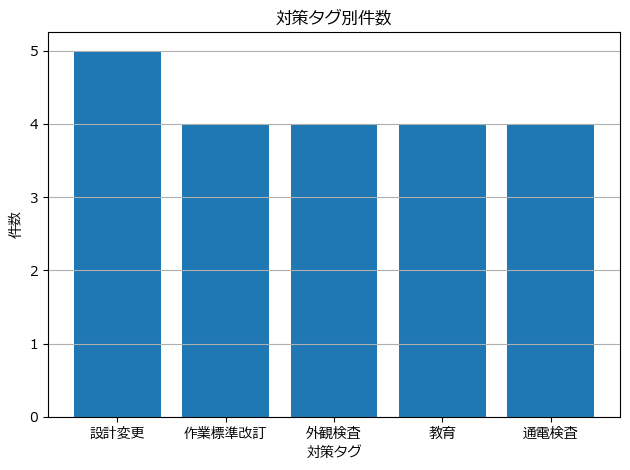

In [33]:
plt.bar(
    df_measure_count["measure"],
    df_measure_count["count"],
)

plt.title("対策タグ別件数")
plt.xlabel("対策タグ")
plt.ylabel("件数")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [35]:
df_site_electrical_count = df.groupby(
    "site",
    as_index=False,
)["通電検査"].sum()
df_site_electrical_count

,site,通電検査
0,GSE,1
1,MEAX,0
2,MELAC,1
3,META,1
4,SUS,1
5,WSE,0


In [37]:
df_site_electrical_count = df_site_electrical_count.rename(
    columns={
        "通電検査": "electrical_check_count",
    }
)
df_site_electrical_count

,site,electrical_check_count
0,GSE,1
1,MEAX,0
2,MELAC,1
3,META,1
4,SUS,1
5,WSE,0


In [39]:
df_model_design_count = df.groupby(
    "model",
    as_index=False,
)["設計変更"].sum()
df_model_design_count

,model,設計変更
0,310D,3
1,36WA,1
2,3BVT,1
3,J69P,0


In [40]:
df_model_design_count = df_model_design_count.rename(
    columns={
        "設計変更": "design_change_count",
    }
)
df_model_design_count

,model,design_change_count
0,310D,3
1,36WA,1
2,3BVT,1
3,J69P,0


In [42]:
df_month_standard_count = df.groupby(
    "occ_month",
    as_index=False,
)["作業標準改訂"].sum()
df_month_standard_count

,occ_month,作業標準改訂
0,2026-07,1
1,2026-08,1
2,2026-09,1
3,2026-10,1


In [43]:
df_month_standard_count = df_month_standard_count.rename(
    columns={
        "作業標準改訂": "standard_revision_count",
    }
)
df_month_standard_count

,occ_month,standard_revision_count
0,2026-07,1
1,2026-08,1
2,2026-09,1
3,2026-10,1


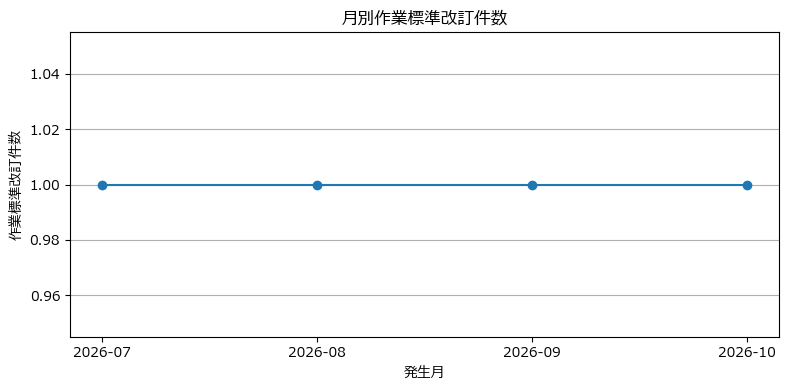

In [47]:
plt.figure(figsize=(8, 4))

plt.plot(
    df_month_standard_count["occ_month"],
    df_month_standard_count["standard_revision_count"],
    marker="o",
)

plt.title("月別作業標準改訂件数")
plt.xlabel("発生月")
plt.ylabel("作業標準改訂件数")
plt.grid(axis="y")

plt.tight_layout()
plt.show()